In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataframe_world_happiness = pd.read_csv("../data/world-happiness-report-2019.csv")

In [4]:
dataframe_world_happiness

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy
0,Finland,1,4,41.0,10.0,2.0,5.0,4.0,47.0,22.0,27.0
1,Denmark,2,13,24.0,26.0,4.0,6.0,3.0,22.0,14.0,23.0
2,Norway,3,8,16.0,29.0,3.0,3.0,8.0,11.0,7.0,12.0
3,Iceland,4,9,3.0,3.0,1.0,7.0,45.0,3.0,15.0,13.0
4,Netherlands,5,1,12.0,25.0,15.0,19.0,12.0,7.0,12.0,18.0
...,...,...,...,...,...,...,...,...,...,...,...
151,Rwanda,152,63,54.0,102.0,144.0,21.0,2.0,90.0,132.0,103.0
152,Tanzania,153,122,78.0,50.0,131.0,78.0,34.0,49.0,125.0,118.0
153,Afghanistan,154,25,152.0,133.0,151.0,155.0,136.0,137.0,134.0,139.0
154,Central African Republic,155,117,132.0,153.0,155.0,133.0,122.0,113.0,152.0,150.0


## Missing values

In [5]:
dataframe_world_happiness.isnull().sum()

Country (region)            0
Ladder                      0
SD of Ladder                0
Positive affect             1
Negative affect             1
Social support              1
Freedom                     1
Corruption                  8
Generosity                  1
Log of GDP\nper capita      4
Healthy life\nexpectancy    6
dtype: int64

In [6]:
dataframe_world_happiness[dataframe_world_happiness.isnull().any(axis=1)]

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy
20,United Arab Emirates,21,65,43.0,56.0,72.0,4.0,NaN,15.0,4.0,60.0
24,Taiwan,25,37,17.0,1.0,48.0,102.0,56.0,56.0,NaN,NaN
27,Saudi Arabia,28,93,49.0,82.0,62.0,68.0,NaN,82.0,11.0,74.0
28,Qatar,29,86,NaN,NaN,NaN,NaN,NaN,NaN,1.0,43.0
36,Bahrain,37,83,39.0,83.0,59.0,24.0,NaN,23.0,20.0,42.0
45,Kosovo,46,107,71.0,7.0,85.0,50.0,144.0,31.0,88.0,NaN
50,Kuwait,51,98,89.0,97.0,69.0,47.0,NaN,42.0,5.0,70.0
63,Northern Cyprus,64,35,144.0,90.0,81.0,77.0,29.0,43.0,NaN,NaN
75,Hong Kong,76,33,105.0,28.0,76.0,66.0,14.0,18.0,9.0,NaN
86,Turkmenistan,87,2,135.0,63.0,8.0,83.0,NaN,33.0,60.0,100.0


Qatar has many NaN values, which may lead to incorrect ranking.
Therefore, removing this entry seems to be the best option.

Other missing values in the dataset are replaced with the mean of their columns.

In [7]:
dataframe_world_happiness.drop(28, inplace=True) # drop Qatar

In [8]:
# replace nan with mean
dataframe_world_happiness.fillna({
    "Corruption": dataframe_world_happiness["Corruption"].mean(),
    "Log of GDP\nper capita": dataframe_world_happiness["Log of GDP\nper capita"].mean(),
    "Healthy life\nexpectancy": dataframe_world_happiness["Healthy life\nexpectancy"].mean()
}, inplace=True)

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy
0,Finland,1,4,41.0,10.0,2.0,5.0,4.0,47.0,22.0,27.0
1,Denmark,2,13,24.0,26.0,4.0,6.0,3.0,22.0,14.0,23.0
2,Norway,3,8,16.0,29.0,3.0,3.0,8.0,11.0,7.0,12.0
3,Iceland,4,9,3.0,3.0,1.0,7.0,45.0,3.0,15.0,13.0
4,Netherlands,5,1,12.0,25.0,15.0,19.0,12.0,7.0,12.0,18.0
...,...,...,...,...,...,...,...,...,...,...,...
151,Rwanda,152,63,54.0,102.0,144.0,21.0,2.0,90.0,132.0,103.0
152,Tanzania,153,122,78.0,50.0,131.0,78.0,34.0,49.0,125.0,118.0
153,Afghanistan,154,25,152.0,133.0,151.0,155.0,136.0,137.0,134.0,139.0
154,Central African Republic,155,117,132.0,153.0,155.0,133.0,122.0,113.0,152.0,150.0


In [9]:
dataframe_world_happiness[dataframe_world_happiness.isnull().any(axis=1)] # there are no more nan values

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy


## Exploratory Data Analysis

### Correlations
Correlation is important because it helps us understand the relationships between data. High correlation (close to +1 or -1), suggests a strong relationship between two variables
- ***Healthy life\nexpectancy*** has the highest positive correlation with ***Log of GDP\nper capita***
- Values above 0.75 are higly corelated
- There are no negative correlations
- Low correlation means little to no relationship between variables. In regression, this is beneficial between features (independent variables) because it helps better predict the dependent variable.



In [10]:
import seaborn as sns

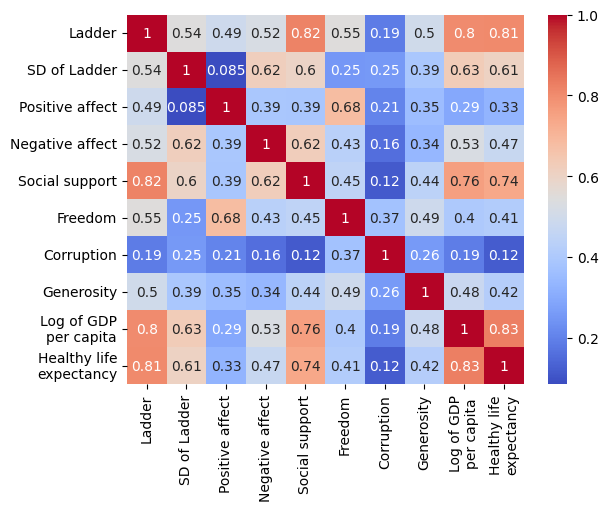

In [11]:
sns.heatmap(dataframe_world_happiness.drop("Country (region)", axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

## Outliers
Outliers are data points that significantly differ from the rest of the observations in a dataset. They are often removed or replaced with more representative values.

In our dataset, there are no significant outliers.

A boxplot is a useful tool for visualizing outliers. (Although the figures appear identical, this is purely coincidental.)

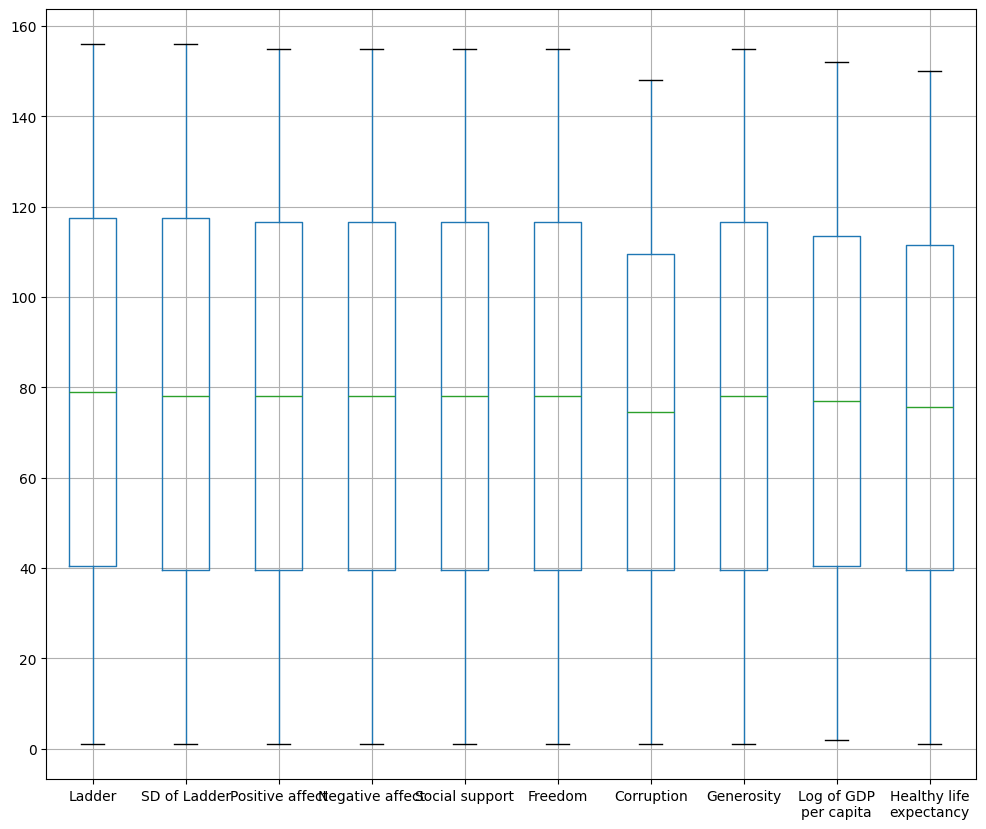

In [12]:
boxplot = dataframe_world_happiness.boxplot(column=['Ladder',	'SD of Ladder',	'Positive affect',	'Negative affect', 'Social support', 'Freedom',	'Corruption', 'Generosity', 'Log of GDP\nper capita', 'Healthy life\nexpectancy'], figsize=(12,10))
plt.show()

Some extra visualization for undestanding the dataset, the highest correlated data was selected.

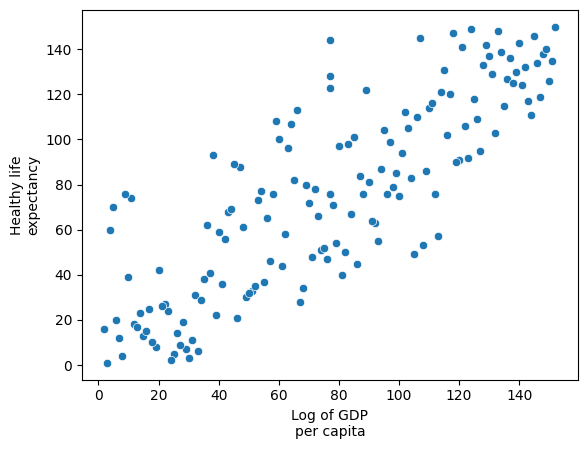

In [13]:
sns.scatterplot(data=dataframe_world_happiness, x="Log of GDP\nper capita", y="Healthy life\nexpectancy")
plt.ylabel("Healthy life\nexpectancy")
plt.show()

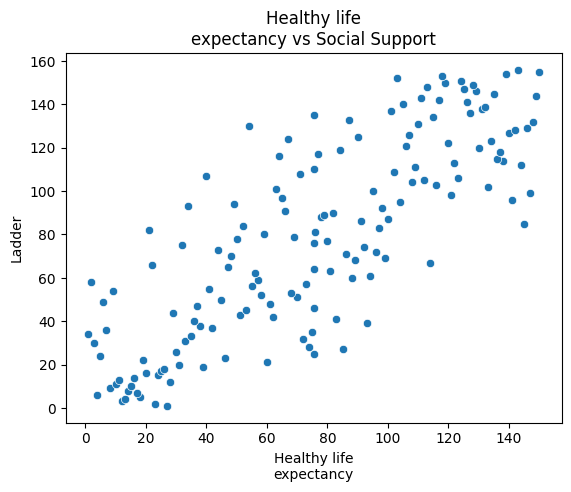

In [14]:
sns.scatterplot(data=dataframe_world_happiness, x="Healthy life\nexpectancy", y="Ladder")
plt.title("Healthy life\nexpectancy vs Social Support")
plt.show()

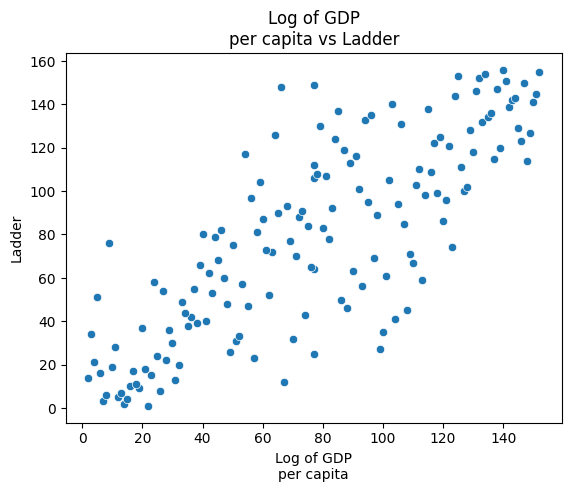

In [15]:
sns.scatterplot(data=dataframe_world_happiness, x="Log of GDP\nper capita", y="Ladder")
plt.title("Log of GDP\nper capita vs Ladder")
plt.show()

## Distributions

Understanding the distribution of data helps us see its overall shape and patterns. If the distribution is abnormal (for example, some values appear very frequently while others are rare), it may need to be transformed or adjusted to improve analysis.

In our case, the distribution is acceptable and does not require adjustment.

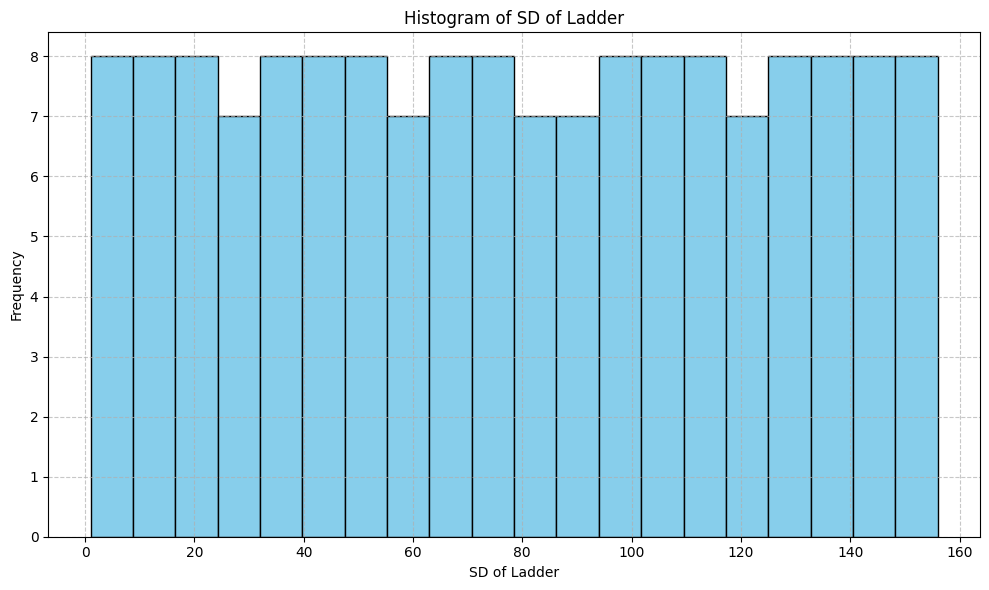

In [16]:
import matplotlib.pyplot as plt

def plotDataHistogram(x, variableName, bins=20):
    plt.figure(figsize=(10, 6))
    plt.hist(x.dropna(), bins=bins, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {variableName}")
    plt.xlabel(variableName)
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


plotDataHistogram(dataframe_world_happiness["SD of Ladder"], "SD of Ladder")
# Country (region) 	Ladder 	SD of Ladder 	Positive affect 	Negative affect 	Social support 	Freedom 	Corruption 	Generosity 	Log of GDP\nper capita 	Healthy life\nexpectancy

# Train

In [17]:
dataframe_world_happiness

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy
0,Finland,1,4,41.0,10.0,2.0,5.0,4.0,47.0,22.0,27.0
1,Denmark,2,13,24.0,26.0,4.0,6.0,3.0,22.0,14.0,23.0
2,Norway,3,8,16.0,29.0,3.0,3.0,8.0,11.0,7.0,12.0
3,Iceland,4,9,3.0,3.0,1.0,7.0,45.0,3.0,15.0,13.0
4,Netherlands,5,1,12.0,25.0,15.0,19.0,12.0,7.0,12.0,18.0
...,...,...,...,...,...,...,...,...,...,...,...
151,Rwanda,152,63,54.0,102.0,144.0,21.0,2.0,90.0,132.0,103.0
152,Tanzania,153,122,78.0,50.0,131.0,78.0,34.0,49.0,125.0,118.0
153,Afghanistan,154,25,152.0,133.0,151.0,155.0,136.0,137.0,134.0,139.0
154,Central African Republic,155,117,132.0,153.0,155.0,133.0,122.0,113.0,152.0,150.0


In [18]:
# use only GDP to predict the Ladder score

X = dataframe_world_happiness[["Log of GDP\nper capita"]]
y = dataframe_world_happiness["Ladder"]

In [19]:
import sys
print(sys.executable)

c:\Users\mraic\.pyenv\pyenv-win\versions\3.12.7\python.exe


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

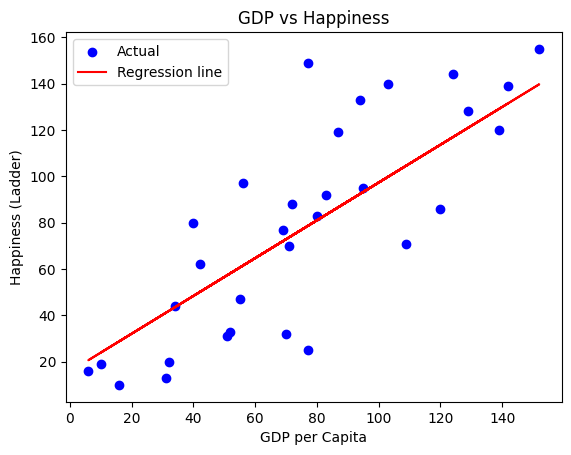

In [22]:
import matplotlib.pyplot as plt

# scatter plot (actual data)
plt.scatter(X_test, y_test, color="blue", label="Actual")

# regression line
plt.plot(X_test, y_pred, color="red", label="Regression line")

plt.xlabel("GDP per Capita")
plt.ylabel("Happiness (Ladder)")
plt.title("GDP vs Happiness")
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 21.37749053995571
MSE: 733.6973755936838
RMSE: 27.086848757167818
R2: 0.6450811646681824


### Use:
- Social support
- Healthy life expectancy
- Log of GDP per capita
- Freedom

## To predict
- Ladder

In [24]:
#split the dataset in train and test
from sklearn.model_selection import train_test_split
X = dataframe_world_happiness[
    ["Social support", "Healthy life\nexpectancy", "Log of GDP\nper capita", "Freedom"]
]
y = dataframe_world_happiness["Ladder"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 15.401170865584737
MSE: 400.88485747899915
RMSE: 20.02210921653858
R2: 0.806075922510315


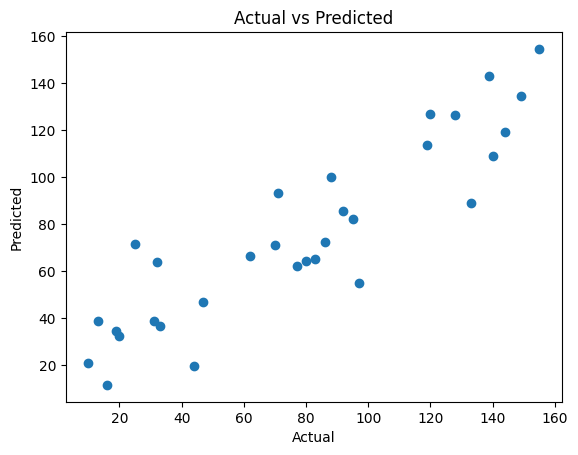

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 15.59225660555332
MSE: 406.89765421380775
RMSE: 20.171704296211754
R2: 0.8031672916698702
